# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)

## 2. Datos

In [2]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')

### 2.1 Exploración de los datos

Filas: 912 | Columnas: 13


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00



--- Calidad de las columnas ---
                     tipo  nulos  unicos
laptop_ID           int64      0     912
Company               str      0      19
Product               str      0     480
TypeName              str      0       6
Inches            float64      0      17
ScreenResolution      str      0      36
Cpu                   str      0     107
Ram                   str      0       9
Memory                str      0      37
Gpu                   str      0      93
OpSys                 str      0       9
Weight                str      0     165
Price_in_euros    float64      0     603

--- Target: Price_in_euros ---
count     912.00
mean     1111.72
std       687.96
min       174.00
25%       589.00
50%       978.00
75%      1483.94
max      6099.00


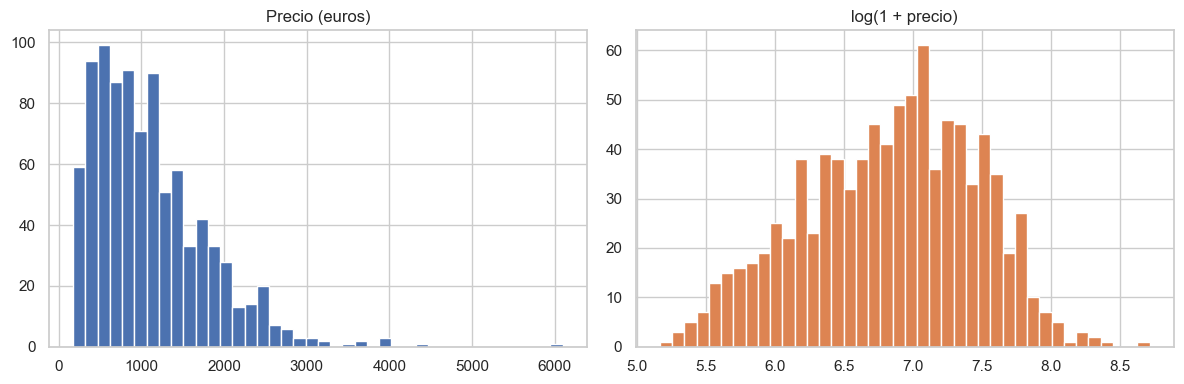


--- Columnas que son texto pero esconden un numero ---
  Ram                -> 8GB
  Weight             -> 1.86kg
  Memory             -> 256GB SSD
  ScreenResolution   -> Full HD 1920x1080
  Cpu                -> Intel Core i3 6006U 2GHz


In [3]:
# forma del dataset y primeras filas
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
display(df.head())

# tipos, nulos y cardinalidad de cada columna
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "unicos": df.nunique(),
})
print("\n--- Calidad de las columnas ---")
print(resumen.to_string())

# el target
print("\n--- Target: Price_in_euros ---")
print(df["Price_in_euros"].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Price_in_euros"].hist(bins=40, ax=axes[0], color="#4c72b0")
axes[0].set_title("Precio (euros)")
np.log1p(df["Price_in_euros"]).hist(bins=40, ax=axes[1], color="#dd8452")
axes[1].set_title("log(1 + precio)")
plt.tight_layout()
plt.show()

# El precio esta sesgado a la derecha (de 174 a 6099 euros, media 1112 pero mediana
# 978). Con el log queda casi simetrico, asi que entrenare sobre log1p(y) y desharé
# el log con expm1 al predecir. Ojo: la metrica se mide en euros, sobre el precio real.

print("\n--- Columnas que son texto pero esconden un numero ---")
for c in ["Ram", "Weight", "Memory", "ScreenResolution", "Cpu"]:
    print(f"  {c:<18} -> {df[c].iloc[0]}")

### 2.2 Definir X e y


In [4]:
# Muchas columnas son texto con un numero dentro (Ram "8GB", Weight "1.86kg"...).
# Las paso a numero con una funcion, porque tendre que aplicar EXACTAMENTE lo mismo
# al test.csv en la seccion 7. Son transformaciones fila a fila: no aprenden nada
# del conjunto, asi que no producen data leakage.

def preparar(datos: pd.DataFrame) -> pd.DataFrame:
    """Extrae variables numericas utiles de las columnas de texto."""
    d = datos.copy()

    # "8GB" -> 8   |   "1.86kg" -> 1.86
    d["Ram_GB"] = d["Ram"].str.replace("GB", "", regex=False).astype(int)
    d["Weight_kg"] = d["Weight"].str.replace("kg", "", regex=False).astype(float)

    # de "IPS Panel Full HD 1920x1080" saco resolucion, densidad de pixeles y dos flags
    res = d["ScreenResolution"].str.extract(r"(\d+)x(\d+)").astype(int)
    d["X_res"], d["Y_res"] = res[0], res[1]
    d["PPI"] = np.sqrt(d["X_res"] ** 2 + d["Y_res"] ** 2) / d["Inches"]
    d["Touchscreen"] = d["ScreenResolution"].str.contains("Touch").astype(int)
    d["IPS"] = d["ScreenResolution"].str.contains("IPS").astype(int)

    # de "Intel Core i7 6700HQ 2.6GHz" me quedo con la gama y los GHz
    d["Cpu_brand"] = d["Cpu"].str.split().str[:3].str.join(" ")
    d["Cpu_GHz"] = d["Cpu"].str.extract(r"(\d+\.?\d*)GHz").astype(float)

    # "128GB SSD +  1TB HDD" -> cuantos GB hay de cada tipo de almacenamiento
    def parse_memoria(texto):
        gb = {"SSD_GB": 0.0, "HDD_GB": 0.0, "Flash_GB": 0.0, "Hybrid_GB": 0.0}
        for trozo in texto.split("+"):
            m = re.match(r"(\d+\.?\d*)(TB|GB)", trozo.strip())
            if not m:
                continue
            cantidad = float(m.group(1)) * (1024 if m.group(2) == "TB" else 1)
            if "SSD" in trozo:
                gb["SSD_GB"] += cantidad
            elif "HDD" in trozo:
                gb["HDD_GB"] += cantidad
            elif "Flash" in trozo:
                gb["Flash_GB"] += cantidad
            elif "Hybrid" in trozo:
                gb["Hybrid_GB"] += cantidad
        return pd.Series(gb)

    d[["SSD_GB", "HDD_GB", "Flash_GB", "Hybrid_GB"]] = d["Memory"].apply(parse_memoria)

    # de la grafica solo me interesa el fabricante
    d["Gpu_brand"] = d["Gpu"].str.split().str[0]
    return d


NUMERICAS = ["Inches", "Ram_GB", "Weight_kg", "X_res", "Y_res", "PPI",
             "Touchscreen", "IPS", "Cpu_GHz", "SSD_GB", "HDD_GB", "Flash_GB", "Hybrid_GB"]
CATEGORICAS = ["Company", "TypeName", "OpSys", "Cpu_brand", "Gpu_brand"]

df_prep = preparar(df)

# Descarto laptop_ID (es un identificador, no informacion) y Product (480 valores
# distintos en 912 filas: casi un identificador tambien, solo aportaria ruido).
X = df_prep[NUMERICAS + CATEGORICAS]
y = df_prep["Price_in_euros"]

print("X:", X.shape, "| y:", y.shape)
print("Nulos en X:", int(X.isna().sum().sum()))
display(X.head())

X: (912, 18) | y: (912,)
Nulos en X: 0


,Inches,Ram_GB,Weight_kg,X_res,Y_res,PPI,Touchscreen,IPS,Cpu_GHz,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB,Company,TypeName,OpSys,Cpu_brand,Gpu_brand
0,15.6,8,1.86,1920,1080,141.211998,0,0,2.0,256.0,0.0,0.0,0.0,HP,Notebook,Windows 10,Intel Core i3,Intel
1,15.6,16,2.59,1920,1080,141.211998,0,0,2.6,0.0,1024.0,0.0,0.0,Dell,Gaming,Windows 10,Intel Core i7,Nvidia
2,15.6,8,2.04,1920,1080,141.211998,0,0,2.7,0.0,1024.0,0.0,0.0,HP,Notebook,Windows 10,Intel Core i7,Nvidia
3,13.3,8,1.34,1440,900,127.677940,0,0,1.8,0.0,0.0,128.0,0.0,Apple,Ultrabook,macOS,Intel Core i5,Intel
4,15.6,4,2.25,1920,1080,141.211998,0,0,2.0,0.0,1024.0,0.0,0.0,Dell,Notebook,Linux,Intel Core i3,AMD


### 2.3 Dividir en train y test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} portatiles | Test: {X_test.shape[0]} portatiles")
print(f"Precio medio train: {y_train.mean():.0f} EUR | test: {y_test.mean():.0f} EUR")

Train: 729 portatiles | Test: 183 portatiles
Precio medio train: 1104 EUR | test: 1143 EUR


## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

In [6]:
# 1) One-hot de las categoricas. Lo hago por separado en train y test y despues
#    ALINEO las columnas del test con las del train: si una marca solo aparece en
#    test, esa columna no existe en train y hay que rellenarla con 0.
X_train = pd.get_dummies(X_train, columns=CATEGORICAS, drop_first=True)
X_test = pd.get_dummies(X_test, columns=CATEGORICAS, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 2) Escalado. Los arboles no lo necesitan, pero el SVR si, asi que mantengo las
#    dos versiones. IMPORTANTE: .fit() SOLO con X_train, si no habria data leakage.
scaler = StandardScaler()
scaler.fit(X_train)
X_train_sc = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns, index=X_test.index)

print("Features tras el one-hot:", X_train.shape[1])
print("Columnas de test alineadas con train:", list(X_train.columns) == list(X_test.columns))

Features tras el one-hot: 72
Columnas de test alineadas con train: True


## 4. Modelado

### 4.1 Entrenamiento

In [7]:
# Entreno sobre log1p(y) por el sesgo del precio que vi en la exploracion.
y_train_log = np.log1p(y_train)

# Random Forest: no necesita escalado
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_log)

# SVR: si necesita escalado, por eso usa X_train_sc
svr = SVR()
svr.fit(X_train_sc, y_train_log)

print("Random Forest y SVR entrenados.")

Random Forest y SVR entrenados.


### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**.

In [8]:
def evaluar(nombre, modelo, X_eval, y_real):
    """Predice, deshace el log y devuelve el RMSE en euros."""
    pred = np.expm1(modelo.predict(X_eval))
    rmse = root_mean_squared_error(y_real, pred)
    print(f"  {nombre:<26} RMSE = {rmse:8.2f} EUR")
    return rmse


# Baseline: predecir siempre el precio medio. Todo modelo tiene que ganarle.
baseline = np.full(len(y_test), y_train.mean())
print("--- RMSE sobre el test local (menor es mejor) ---")
print(f"  {'Baseline (precio medio)':<26} RMSE = {root_mean_squared_error(y_test, baseline):8.2f} EUR")
rmse_rf = evaluar("Random Forest", rf, X_test, y_test)
rmse_svr = evaluar("SVR", svr, X_test_sc, y_test)

# El Random Forest gana con claridad. El SVR, aun escalado, sufre con las ~80
# columnas que deja el one-hot. Optimizo por tanto el Random Forest.

--- RMSE sobre el test local (menor es mejor) ---
  Baseline (precio medio)    RMSE =   745.51 EUR
  Random Forest              RMSE =   327.70 EUR
  SVR                        RMSE =   353.71 EUR


### 4.3 Optimización (up to you 🫰🏻)

Mejores hiperparametros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
RMSE en CV (en escala log): 0.2086
  Random Forest optimizado   RMSE =   326.57 EUR

Mejora frente al RF por defecto: 1.13 EUR


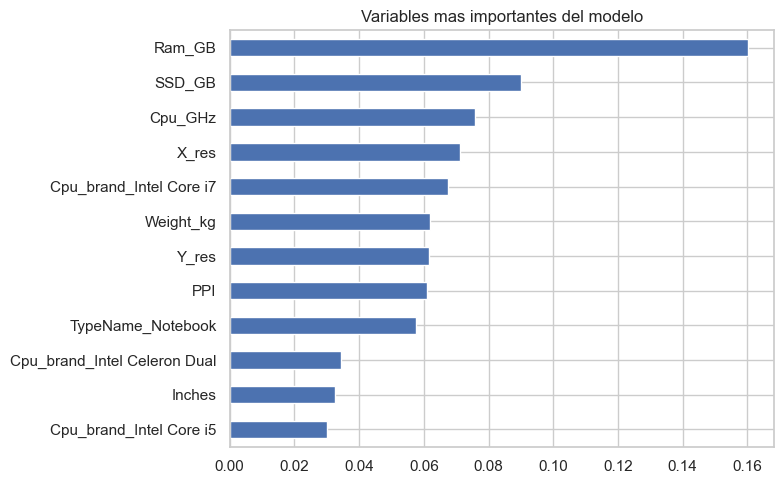

In [9]:
# Grid pequeno pero razonado sobre el Random Forest, con validacion cruzada de 5
# folds y la metrica de la competicion (RMSE). Meto los valores por defecto dentro
# del grid por si ya fueran los mejores.
grid = {
    "n_estimators": [300, 600],
    "max_depth": [None, 20],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.5, 1.0],
}

gs = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
gs.fit(X_train, y_train_log)

print("Mejores hiperparametros:", gs.best_params_)
print(f"RMSE en CV (en escala log): {-gs.best_score_:.4f}")

rf_opt = gs.best_estimator_
rmse_opt = evaluar("Random Forest optimizado", rf_opt, X_test, y_test)
print(f"\nMejora frente al RF por defecto: {rmse_rf - rmse_opt:.2f} EUR")

# Que mira el modelo
importancias = pd.Series(rf_opt.feature_importances_, index=X_train.columns)
plt.figure(figsize=(8, 5))
importancias.sort_values().tail(12).plot(kind="barh", color="#4c72b0")
plt.title("Variables mas importantes del modelo")
plt.tight_layout()
plt.show()

## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [10]:
# Repito el one-hot sobre TODOS los datos de train.csv y reentreno el modelo
# ganador con los mismos hiperparametros. Guardo las columnas resultantes porque
# son exactamente las que tendra que tener el test.csv en la seccion 7.
X_full = pd.get_dummies(X, columns=CATEGORICAS, drop_first=True)
COLUMNAS_MODELO = list(X_full.columns)

modelo_final = RandomForestRegressor(**gs.best_params_, random_state=42, n_jobs=-1)
modelo_final.fit(X_full, np.log1p(y))

print(f"Modelo final reentrenado con {X_full.shape[0]} portatiles y {X_full.shape[1]} features.")

Modelo final reentrenado con 912 portatiles y 80 features.


---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [11]:
X_pred = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [12]:
# Mismo tratamiento que en train: la funcion preparar() y el mismo one-hot,
# alineando con las columnas que espera el modelo. NO borro ninguna fila.
X_pred_prep = preparar(X_pred)
X_pred_final = X_pred_prep[NUMERICAS + CATEGORICAS]
X_pred_final = pd.get_dummies(X_pred_final, columns=CATEGORICAS, drop_first=True)
X_pred_final = X_pred_final.reindex(columns=COLUMNAS_MODELO, fill_value=0)

print("Filas en test:", X_pred_final.shape[0], "(deben seguir siendo", len(X_pred), ")")
print("Columnas alineadas con el modelo:", list(X_pred_final.columns) == COLUMNAS_MODELO)
print("Nulos:", int(X_pred_final.isna().sum().sum()))

Filas en test: 391 (deben seguir siendo 391 )
Columnas alineadas con el modelo: True
Nulos: 0


## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [13]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [14]:
# Predigo y deshago el log para volver a euros
precios = np.expm1(modelo_final.predict(X_pred_final))

submission = pd.DataFrame({
    "laptop_ID": X_pred["laptop_ID"],
    "Price_in_euros": precios,
})

print(submission.shape)
display(submission.head())
print("\nRango de precios predichos:", f"{precios.min():.0f} - {precios.max():.0f} EUR")

(391, 2)


,laptop_ID,Price_in_euros
0,209,1194.487646
1,1281,289.064293
2,1168,400.320722
3,1231,920.425834
4,1020,995.420259



Rango de precios predichos: 217 - 4003 EUR


### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [15]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [16]:
checker(submission, sample)

 ¡Todo correcto! Submission guardada como 'submission_20260922_165931.csv'. ¡A Kaggle!